In [1]:
# !pip install pandas numpy scikit-learn nltk seaborn matplotlib tensorflow sastrawi

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import LSTM, Embedding, Dense, Input, Dropout, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
import pandas as pd
import re
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

# Download stopwords & wordnet (sekali saja)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load data dari CSV (ganti 'data.csv' dengan file kamu)
df = pd.read_csv('/content/google_play_tokopedia_3000.csv')

# Setup stemmer & stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    stemmed = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed)

# Terapkan fungsi clean_text ke kolom content
df['clean_text'] = df['content'].astype(str).apply(clean_text)

# Cek hasil
print(df[['content', 'clean_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                             content  \
0  si ijo ini sahabat blanja onlen saya sejak 201...   
1                                            Manatap   
2                                       semog@ bener   
3  Pengiriman melalui gosend tolong no tlp custme...   
4  san aja untuk pihat toko pedia cobalah jangan ...   

                                          clean_text  
0  si ijo sahabat blanja onlen start up yg pakai ...  
1                                            manatap  
2                                        semog bener  
3  kirim gosend tolong no tlp custmer samar susah...  
4  san aja pihat toko dia coba pake kurir rekomda...  


In [12]:
df['clean_text'] = df['content'].astype(str).apply(clean_text)

In [13]:
# Label encoding
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)

# Tokenisasi
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded = pad_sequences(sequences, maxlen=100, padding='post')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded, df['label'], test_size=0.2, stratify=df['label'], random_state=42)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

In [14]:
class Attention(tf.keras.layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def call(self, inputs):
        scores = tf.keras.backend.tanh(inputs)
        attention_weights = tf.keras.backend.softmax(scores, axis=1)
        context_vector = attention_weights * inputs
        return tf.keras.backend.sum(context_vector, axis=1)

input_layer = Input(shape=(100,))
embedding = Embedding(input_dim=10000, output_dim=128)(input_layer)
lstm = Bidirectional(LSTM(64, return_sequences=True))(embedding)
attention = Attention()(lstm)
drop = Dropout(0.5)(attention)
output = Dense(num_classes, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,203 (5.26 MB)

 Trainable params: 1,379,203 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.6069 - loss: 0.8615 - val_accuracy: 0.7208 - val_loss: 0.7250
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.6450 - loss: 0.7765 - val_accuracy: 0.8188 - val_loss: 0.5325
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.7575 - loss: 0.6477 - val_accuracy: 0.7917 - val_loss: 0.5431
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.7800 - loss: 0.5952 - val_accuracy: 0.8104 - val_loss: 0.4888
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.8266 - loss: 0.5232 - val_accuracy: 0.8396 - val_loss: 0.4599
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.8536 - loss: 0.4688 - val_accuracy: 0.8625 - val_loss: 0.3874
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8860 - loss: 0.3835 - val_accuracy: 0.8854 - val_loss: 0.3550
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.9059 - loss: 0.3061 - val_accurac

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8735 - loss: 0.4464
Accuracy: 86.67%
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.74      0.94      0.82       178
     neutral       0.00      0.00      0.00        27
    positive       0.95      0.89      0.92       395

    accuracy                           0.87       600
   macro avg       0.56      0.61      0.58       600
weighted avg       0.84      0.87      0.85       600



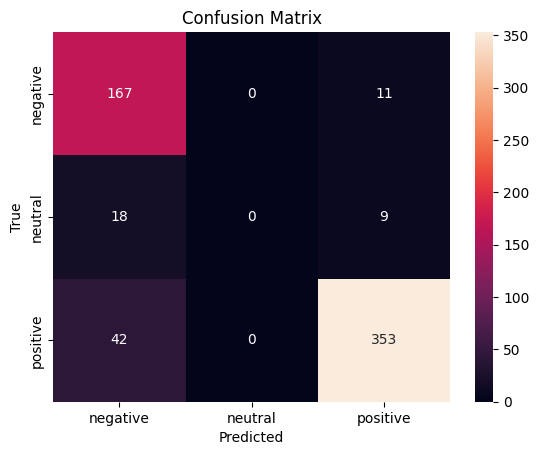

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediksi sentimen: positive


In [16]:
# Evaluasi
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"Accuracy: {acc * 100:.2f}%")

# Classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Contoh inference
sample = ["pengalaman saya sangat buruk, barang tidak dikirim"]
sample_clean = [clean_text(sample[0])]
sample_seq = pad_sequences(tokenizer.texts_to_sequences(sample_clean), maxlen=100)
pred = np.argmax(model.predict(sample_seq), axis=1)
print("Prediksi sentimen:", label_encoder.inverse_transform(pred)[0])